In [1]:
# These modules are required for the data reduction.
from dysh.fits.gbtfitsload import GBTFITSLoad
from astropy import units as u
import numpy as np
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")

15:58:10.014 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [4]:
sdfits = GBTFITSLoad(filename)

15:58:10.234 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


In [6]:
scans = [51,53,55]

In [7]:
ps_scan_block = sdfits.getps(scan=scans, ifnum=0, plnum=0, fdnum=0, units="flux", 
                             zenith_opacity=0.08)

In [8]:
ps_scan_block_ap_eff = sdfits.getps(scan=scans, ifnum=0, plnum=0, fdnum=0, units="flux", 
                                    zenith_opacity=0.08, ap_eff=0.25)

In [9]:
ps_scan_block_surf_err = sdfits.getps(scan=scans, ifnum=0, plnum=0, fdnum=0, units="flux", 
                                      zenith_opacity=0.08, surface_error=400*u.micron)

In [10]:
print(f"{np.mean(ps_scan_block[0].ap_eff):.4f},{np.mean(ps_scan_block_ap_eff[0].ap_eff):.4f},{np.mean(ps_scan_block_surf_err[0].ap_eff):.4f}")

0.6095,0.2500,0.6095


S_nu = 0.209 Jy


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


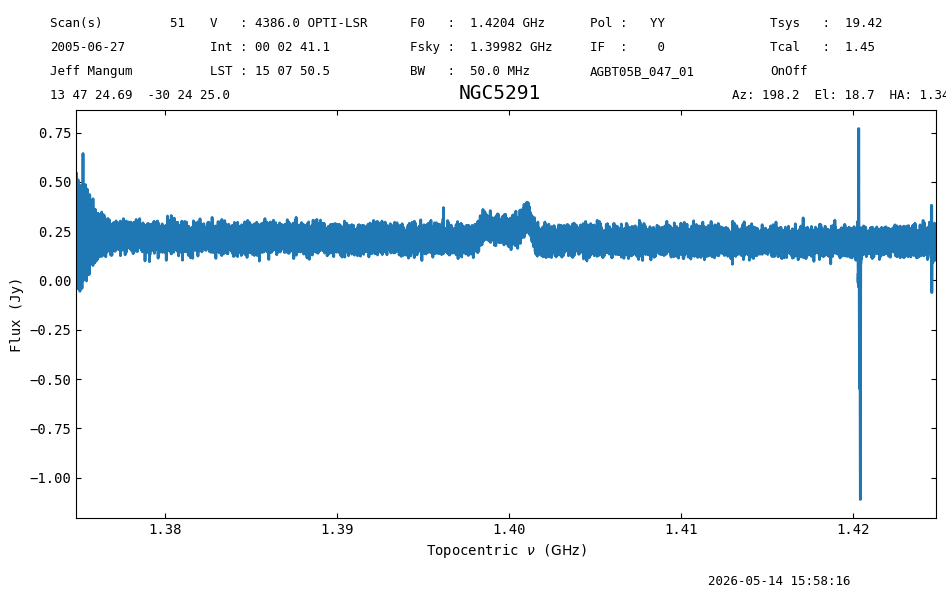

In [11]:
a = ps_scan_block.timeaverage()
print(f"S_nu = {a.stats()['median']:.3}")
a.plot();

S_nu = 0.508 Jy


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


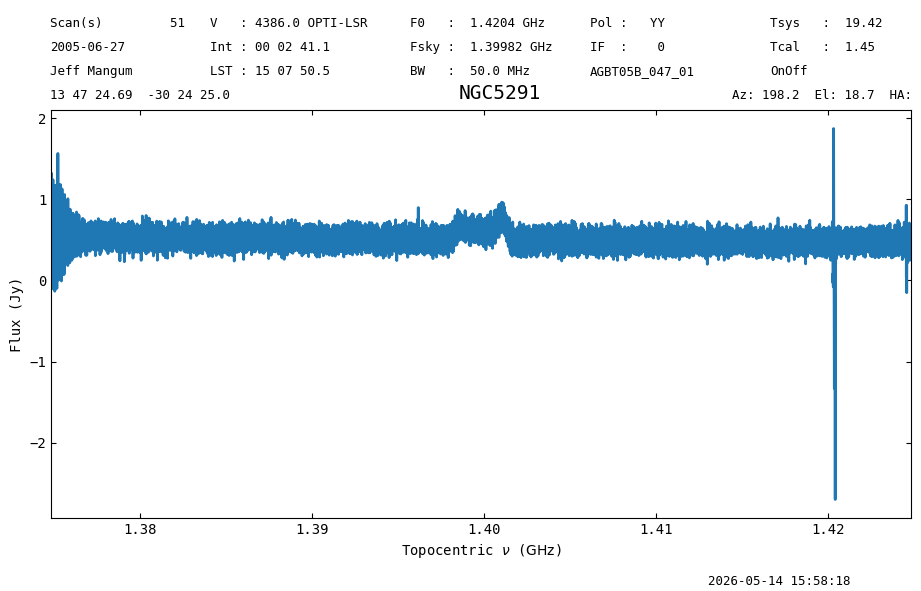

In [12]:
b = ps_scan_block_ap_eff.timeaverage()
print(f"S_nu = {b.stats()['median']:.3}")
b.plot();

In [13]:
print(f"eta = {a.meta['AP_EFF']:.3f}, epsilon = {a.meta['SURF_ERR']:.1f} {a.meta['SE_UNIT']}, tau = {a.meta['TAU_Z']:.2f}")

eta = 0.608, epsilon = 440.0 micron, tau = 0.08


In [14]:
b.check_stats(0.11950689 * u.Jy)

15:58:19.413 I rms is OK 
